In [2]:
import squidpy as sq
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os
import numpy as np

In [3]:
PATH = "/dfs3b/ruic20_lab/tingty7/projects/humen_eye_xenium/surface_combine/spatial_plots"
files = glob.glob(os.path.join(PATH, "*.h5ad"))

len(files)

6

In [4]:
files.sort()

In [5]:
files

['/dfs3b/ruic20_lab/tingty7/projects/humen_eye_xenium/surface_combine/spatial_plots/sec01_object.h5ad',
 '/dfs3b/ruic20_lab/tingty7/projects/humen_eye_xenium/surface_combine/spatial_plots/sec02_object.h5ad',
 '/dfs3b/ruic20_lab/tingty7/projects/humen_eye_xenium/surface_combine/spatial_plots/sec03_object.h5ad',
 '/dfs3b/ruic20_lab/tingty7/projects/humen_eye_xenium/surface_combine/spatial_plots/sec04_object.h5ad',
 '/dfs3b/ruic20_lab/tingty7/projects/humen_eye_xenium/surface_combine/spatial_plots/sec05_object.h5ad',
 '/dfs3b/ruic20_lab/tingty7/projects/humen_eye_xenium/surface_combine/spatial_plots/sec06_object.h5ad']

sec01_object


  0%|          | 0/1000 [00:00<?, ?/s]

/opt/apps/python/3.10.2/lib/python3.10/site-packages/squidpy/gr/_nhood.py:199: RuntimeWarning: invalid value encountered in divide
  zscore = (count - perms.mean(axis=0)) / perms.std(axis=0)
/opt/apps/python/3.10.2/lib/python3.10/site-packages/anndata/_core/anndata.py:430: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/opt/apps/python/3.10.2/lib/python3.10/site-packages/squidpy/pl/_utils.py:557: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  row_labels = adata.obs[key][row_order]


sec02_object


  0%|          | 0/1000 [00:00<?, ?/s]

...

  0%|          | 0/1000 [00:00<?, ?/s]

/opt/apps/python/3.10.2/lib/python3.10/site-packages/anndata/_core/anndata.py:430: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/opt/apps/python/3.10.2/lib/python3.10/site-packages/squidpy/pl/_utils.py:557: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  row_labels = adata.obs[key][row_order]


sec06_object


  0%|          | 0/1000 [00:00<?, ?/s]

/opt/apps/python/3.10.2/lib/python3.10/site-packages/anndata/_core/anndata.py:430: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/opt/apps/python/3.10.2/lib/python3.10/site-packages/squidpy/pl/_utils.py:557: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  row_labels = adata.obs[key][row_order]


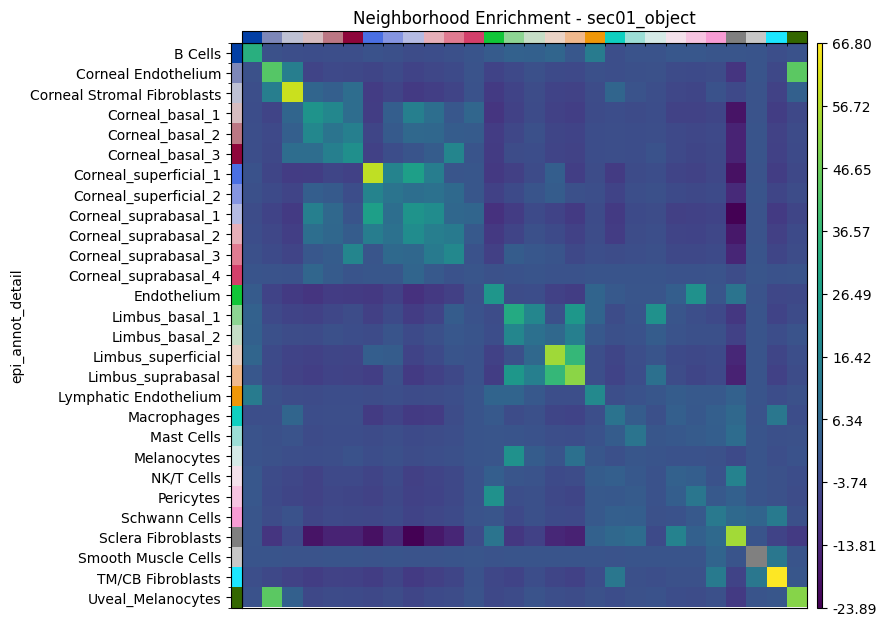

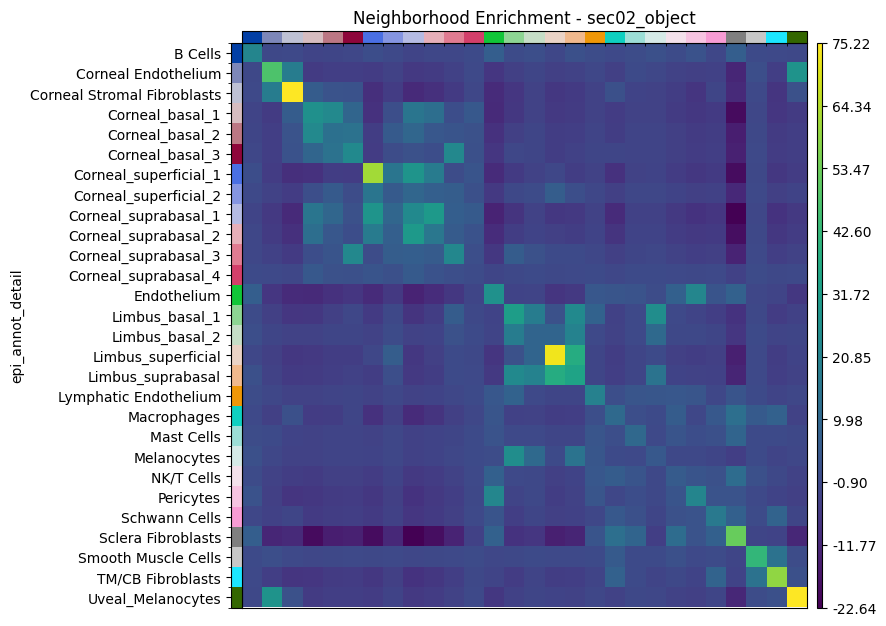

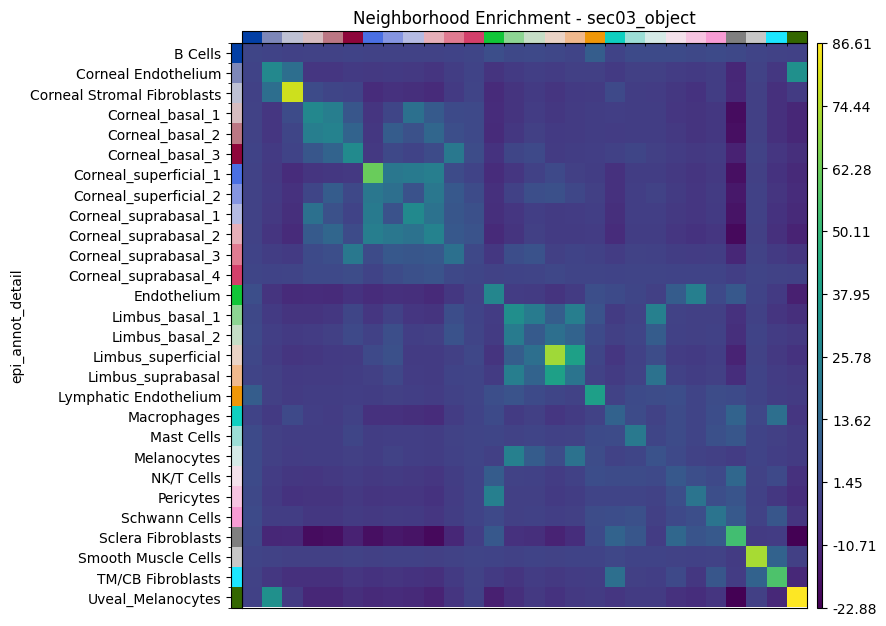

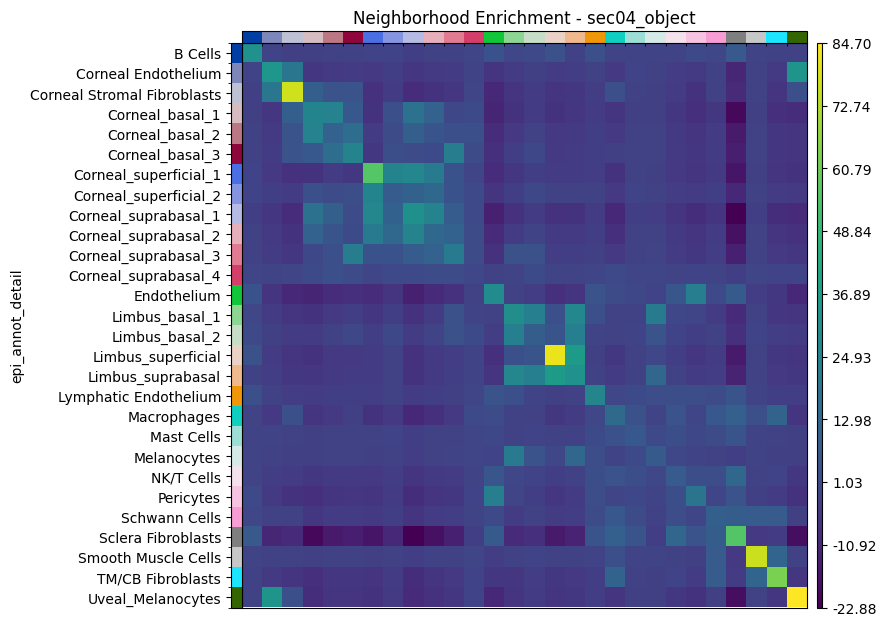

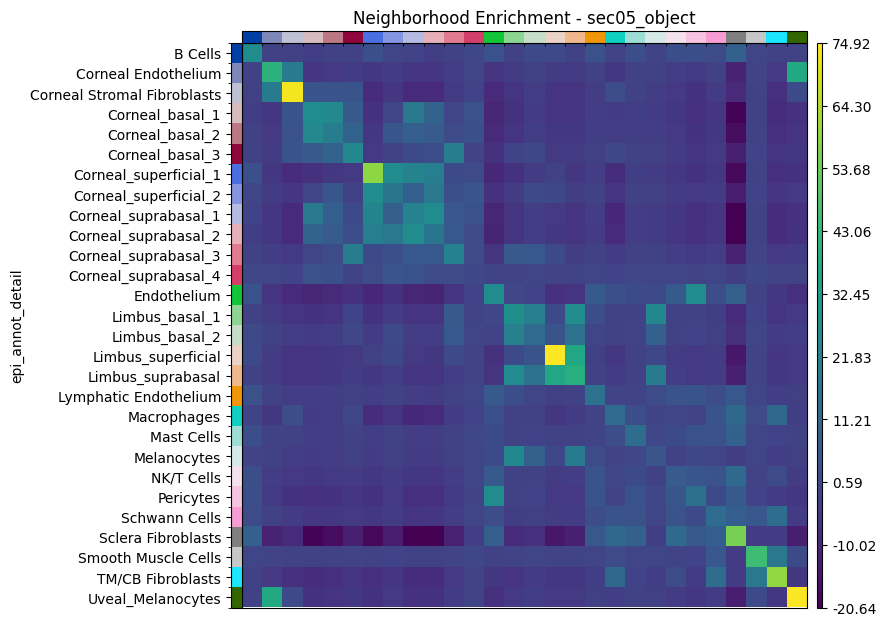

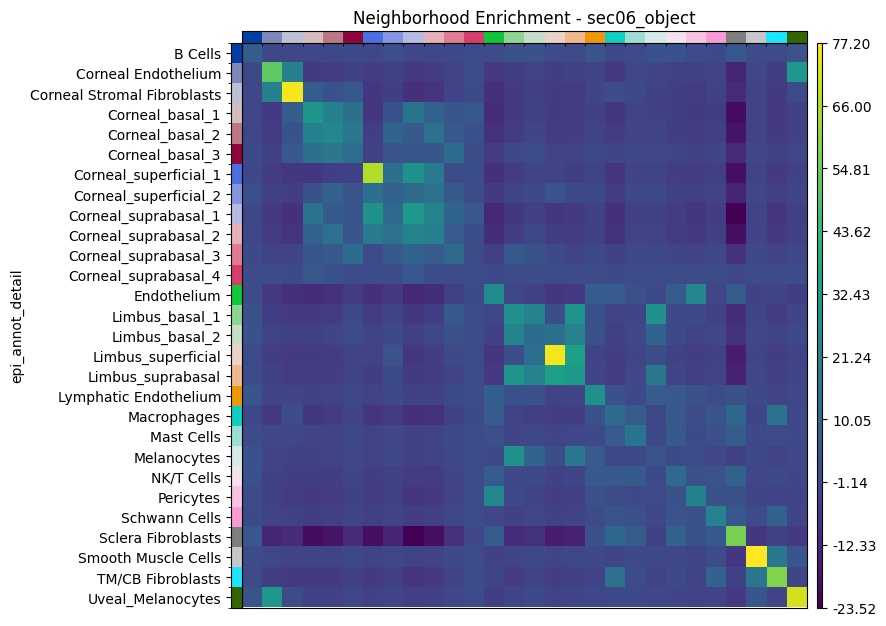

In [7]:
zscore_df_list = []

for file in files:
    sampleid = os.path.splitext(os.path.basename(file))[0]
    print(sampleid)
    #print(file)
    adata = sc.read_h5ad(file)
    metadata_PATH = "/dfs3b/ruic20_lab/tingty7/projects/humen_eye_xenium/surface_combine/spatial_plots/" + sampleid + "_metadata.csv"
    
    metadata = pd.read_csv(metadata_PATH, low_memory=False)
    metadata.index = metadata["barcode"]
    metadata.index.name=None
    metadata["epi_annot_detail"] = pd.Categorical(metadata["epi_annot_detail"])
    adata.obs = metadata
    
    adata.obsm["spatial"] = adata.obs[['x', 'y']].to_numpy()
    sq.gr.spatial_neighbors(adata, coord_type="generic", delaunay=True)
    sq.gr.nhood_enrichment(adata, cluster_key="epi_annot_detail")
    
    sq.pl.nhood_enrichment(
        adata,
        cluster_key="epi_annot_detail",
        figsize=(6, 6),
        title="Neighborhood Enrichment - " + sampleid,
        save= sampleid + "_nhood_enrichment.pdf"
    )
    
    labels = adata.obs["epi_annot_detail"].cat.categories.tolist()
    matrix_df = pd.DataFrame(adata.uns['epi_annot_detail_nhood_enrichment']['zscore'], index=labels, columns=labels)
    matrix_df.to_csv("nhood_enrichment_matrix/" + sampleid + "_nhood_enrichment_zscore.txt", sep = " ", index=True, header=True, index_label="index")
    zscore_df_list.append(matrix_df)
        
    

In [9]:
import pickle

with open("zscore_df_list.pkl", "wb") as f:
    pickle.dump(zscore_df_list, f)

In [11]:
all_rows = set()
all_cols = set()
for df in zscore_df_list:
    all_rows.update(df.index)
    all_cols.update(df.columns)

# Sort for consistent order (optional)
all_rows = sorted(all_rows)
all_cols = sorted(all_cols)

# Final 17x17 reference
final_index = all_rows
final_columns = all_cols


In [12]:
# Reindex all dfs to the same 17x17 structure with zeros filled
standardized_dfs = [
    df.reindex(index=final_index, columns=final_columns)
    for df in zscore_df_list
]


In [13]:
data_array = np.stack([df.values for df in standardized_dfs])

In [14]:
mean_matrix = np.nanmean(data_array, axis=0)
mean_df = pd.DataFrame(mean_matrix, index=final_index, columns=final_columns)
mean_df

,B Cells,Corneal Endothelium,Corneal Stromal Fibroblasts,Corneal_basal_1,Corneal_basal_2,Corneal_basal_3,Corneal_superficial_1,Corneal_superficial_2,Corneal_suprabasal_1,Corneal_suprabasal_2,...,Macrophages,Mast Cells,Melanocytes,NK/T Cells,Pericytes,Schwann Cells,Sclera Fibroblasts,Smooth Muscle Cells,TM/CB Fibroblasts,Uveal_Melanocytes
B Cells,19.878974,-1.378523,-1.943573,-2.295917,-1.874143,-1.641478,-0.313734,-0.777203,-2.149067,-2.009381,...,-1.245759,0.293768,0.375007,0.897974,1.146549,0.091716,4.557648,-0.473544,-1.403651,-1.067393
Corneal Endothelium,-1.378523,41.019533,18.053836,-5.601547,-4.849610,-4.075625,-5.125790,-3.641387,-5.876952,-5.329047,...,-4.521800,-1.653390,-1.915555,-3.400728,-4.173454,-2.749894,-11.354337,-0.886818,-4.664110,34.008064
Corneal Stromal Fibroblasts,-1.943573,18.053836,73.119913,5.645791,2.782377,3.693896,-8.302458,-5.452341,-9.296551,-8.298533,...,2.284996,-2.165856,-3.050085,-4.753700,-6.491255,-2.549820,-9.233145,-1.811503,-6.921255,0.935405
Corneal_basal_1,-2.295917,-5.601547,5.645791,26.312182,22.581154,8.426947,-7.291687,1.481776,16.411885,9.717282,...,-4.642529,-3.012005,-3.087725,-5.424127,-6.878248,-5.309483,-19.631590,-1.965938,-7.513594,-6.667300
Corneal_basal_2,-1.874143,-4.849610,2.782377,22.581154,17.240954,13.915895,-4.825225,5.289984,7.237494,8.262774,...,-4.085226,-2.675321,-2.694020,-4.416337,-5.943198,-4.593766,-16.333075,-1.701398,-6.539944,-5.770872
Corneal_basal_3,-1.641478,-4.075625,3.693896,8.426947,13.915895,22.728468,-5.000272,0.393913,1.149375,1.956043,...,-1.881296,-1.802287,-2.066950,-3.681380,-5.018725,-3.846187,-13.081095,-1.356730,-5.446112,-4.993938
Corneal_superficial_1,-0.313734,-5.125790,-8.302458,-7.291687,-4.825225,-5.000272,60.377850,19.591813,25.746870,19.406217,...,-7.919957,-2.905279,-2.916625,-5.068707,-6.318504,-4.938847,-18.776436,-1.847544,-6.992511,-6.127867
Corneal_superficial_2,-0.777203,-3.641387,-5.452341,1.481776,5.289984,0.393913,19.591813,11.028094,8.875887,13.858765,...,-5.608044,-2.008076,-1.702895,-3.545721,-4.493117,-3.474768,-12.965942,-1.255961,-4.901818,-4.456016
Corneal_suprabasal_1,-2.149067,-5.876952,-9.296551,16.411885,7.237494,1.149375,25.746870,8.875887,26.454625,23.479148,...,-9.571958,-3.314085,-3.347146,-5.880847,-7.453522,-5.802989,-21.749128,-2.110388,-8.016548,-7.018172
Corneal_suprabasal_2,-2.009381,-5.329047,-8.298533,9.717282,8.262774,1.956043,19.406217,13.858765,23.479148,17.632306,...,-8.520241,-2.926450,-2.885351,-5.165191,-6.655427,-5.065916,-19.161373,-1.873207,-7.106902,-6.497957


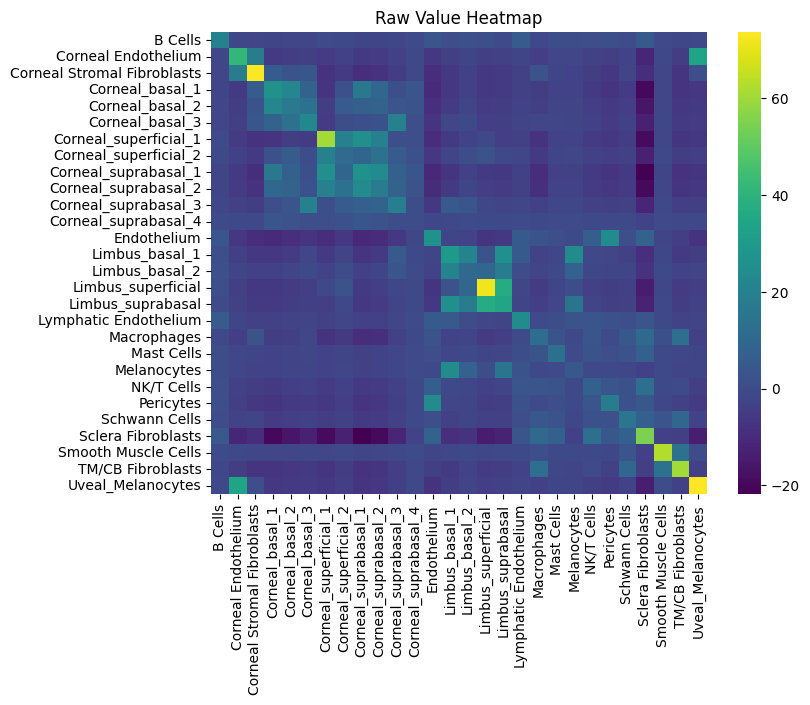

In [16]:
plt.figure(figsize=(8, 6))
sns.heatmap(mean_df, annot=False, cmap="viridis")#, vmin=-170, vmax=250)  # No scaling applied
plt.title("Raw Value Heatmap")
plt.show()

In [17]:
# For each (i,j) position, collect the 85 values
all_values = []
for i, row in enumerate(final_index):
    for j, col in enumerate(final_columns):
        values = [df.loc[row, col] for df in standardized_dfs]
        all_values.append({
            "row": row,
            "col": col,
            "values": values  # list of 85 values
        })

# Optionally convert to DataFrame with exploded rows
flat_df = pd.DataFrame([
    {"row": d["row"], "col": d["col"], "index": k, "value": v}
    for d in all_values for k, v in enumerate(d["values"])
])


In [19]:
flat_df.to_csv("flat_df.csv")